# 2.1. Install and import dependencies

In [1]:
!pip install poetry --quiet

In [2]:
import os

# Write pyproject.toml at the repo root
repo_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
os.chdir(repo_root)

pyproject_content = """\
[tool.poetry]
name = "ml-engineering-lab02"
description = "CIFAR-10 automated dataset extension pipeline"
authors = ["Yehor <yehor.chukanov@cs.khpi.edu.ua>"]
version = "0.1.0"

[tool.poetry.dependencies]
python = "~3.11"
torch = {version = ">=2.5.0", source = "pytorch"}
torchvision = {version = ">=0.20.0", source = "pytorch"}
tqdm = ">=4.66"
matplotlib = ">=3.8"
numpy = ">=1.24,<2.0"
pyyaml = ">=6.0"
pandas = ">=2.0"
requests = ">=2.31"
scikit-learn = ">=1.3"

[tool.poetry.group.dev.dependencies]
mypy = ">=1.8"
ruff = ">=0.2"
black = ">=24.0"
isort = ">=5.13"
ipykernel = ">=6.29"

[[tool.poetry.source]]
name = "pytorch"
priority = "supplemental"
url = "https://download.pytorch.org/whl/cu128"

[tool.black]
line-length = 100

[tool.isort]
profile = "black"
line_length = 100

[tool.ruff]
line-length = 100

[tool.mypy]
python_version = "3.11"
warn_return_any = true
warn_unused_configs = true

[build-system]
requires = ["poetry-core>=1.0.0"]
build-backend = "poetry.core.masonry.api"
"""

with open("pyproject.toml", "w") as f:
    f.write(pyproject_content)

print(f"Created pyproject.toml at {repo_root}")

# Install dependencies
!poetry install --no-root 2>&1 | tail -5

Created pyproject.toml at /home/yehor/study/ml_engineering
Installing dependencies from lock file

No dependencies to install or update


Load configuration from YAML and set up imports.

In [7]:
import logging
import pickle
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import yaml
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logging.info(f"Using device: {device}")

INFO:root:Using device: cuda


In [4]:
# Fix logging in notebooks
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

logging.basicConfig(level=logging.INFO)

# Load config
config_path = Path("labs/lab02/configs/config.yaml")
with open(config_path) as f:
    config = yaml.safe_load(f)

logging.info(f"Config loaded from {config_path}")
config

INFO:root:Config loaded from labs/lab02/configs/config.yaml


{'data': {'data_dir': 'data',
  'cifar_subdir': 'cifar-10-batches-py',
  'test_batch': 'test_batch',
  'random_state': 42},
 'model': {'n_classes': 10},
 'training': {'batch_size': 128,
  'num_workers': 4,
  'num_epochs': 20,
  'learning_rate': 0.001},
 'artifacts': {'save_dir': 'artifacts/lab02',
  'best_model_filename': 'best_model.pth'},
 'experiments': [{'name': '1_train_1_val',
   'train_batches': [1],
   'val_batches': [2]},
  {'name': '2_train_1_val', 'train_batches': [1, 2], 'val_batches': [3]},
  {'name': '3_train_1_val', 'train_batches': [1, 2, 3], 'val_batches': [4]},
  {'name': '4_train_1_val',
   'train_batches': [1, 2, 3, 4],
   'val_batches': [5]}]}

# 2.2 Data loading with batch selection

In [5]:
def _unpickle(file_path: str) -> Dict[bytes, Any]:
    """Load a CIFAR-10 batch file."""
    with open(file_path, "rb") as f:
        batch = pickle.load(f, encoding="bytes")
    return batch  # type: ignore[no-any-return]


def load_batches(
    data_dir: str, batch_ids: List[int]
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load specific CIFAR-10 training batches by their IDs (1-5).

    Args:
        data_dir: Path to the data directory containing cifar-10-batches-py/.
        batch_ids: List of batch numbers to load (e.g. [1, 2, 3]).

    Returns:
        Tuple of (images, labels).
        Images shape: (N, 3, 32, 32), dtype float32, normalized to [0, 1].
    """
    cifar_dir = Path(data_dir) / config["data"]["cifar_subdir"]
    images_list: List[np.ndarray] = []
    labels_list: List[int] = []

    for batch_id in batch_ids:
        batch_file = cifar_dir / f"data_batch_{batch_id}"
        if not batch_file.exists():
            raise FileNotFoundError(f"Batch file not found: {batch_file}")
        batch = _unpickle(str(batch_file))
        images_list.append(batch[b"data"])
        labels_list.extend(batch[b"labels"])

    images = (
        np.concatenate(images_list).reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
    )
    labels = np.array(labels_list, dtype=np.int64)

    logging.info(
        f"Loaded batches {batch_ids}: {images.shape[0]} images"
    )
    return images, labels


def load_test_set(data_dir: str) -> Tuple[np.ndarray, np.ndarray]:
    """
    Load the static CIFAR-10 test batch.

    Returns:
        Tuple of (test_images, test_labels).
    """
    cifar_dir = Path(data_dir) / config["data"]["cifar_subdir"]
    test_batch = _unpickle(str(cifar_dir / config["data"]["test_batch"]))
    test_images = (
        test_batch[b"data"].reshape(-1, 3, 32, 32).astype(np.float32) / 255.0
    )
    test_labels = np.array(test_batch[b"labels"], dtype=np.int64)

    logging.info(f"Loaded static test set: {test_images.shape[0]} images")
    return test_images, test_labels


def process_experiment_data(
    data_dir: str,
    train_batches: List[int],
    val_batches: List[int],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Build dynamic train/val sets from selected batches and load the static test set.

    Args:
        data_dir: Data directory path.
        train_batches: Batch IDs for training (e.g. [1, 2, 3]).
        val_batches: Batch IDs for validation (e.g. [4]).

    Returns:
        (train_images, train_labels, val_images, val_labels, test_images, test_labels)
    """
    train_images, train_labels = load_batches(data_dir, train_batches)
    val_images, val_labels = load_batches(data_dir, val_batches)
    test_images, test_labels = load_test_set(data_dir)

    logging.info(
        f"Data splits — train: {len(train_labels)}, "
        f"val: {len(val_labels)}, test: {len(test_labels)}"
    )
    return train_images, train_labels, val_images, val_labels, test_images, test_labels

# 2.3 Training loop

## 2.3.1 Data loaders

In [8]:
class CifarDataset(Dataset):  # type: ignore[type-arg]
    """Dataset for CIFAR-10 numpy arrays."""

    def __init__(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        transform: Optional[nn.Module] = None,
    ) -> None:
        self.images = torch.from_numpy(images)
        self.labels = torch.from_numpy(labels)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        image = self.images[idx]
        label = int(self.labels[idx])

        if self.transform:
            image = self.transform(image)

        return image, label


def create_data_loader(
    images: np.ndarray,
    labels: np.ndarray,
    config: Dict[str, Any],
    transform: Optional[nn.Module] = None,
    shuffle: bool = True,
) -> DataLoader:  # type: ignore[type-arg]
    """Create a DataLoader from numpy arrays."""
    dataset = CifarDataset(images, labels, transform=transform)
    data_loader: DataLoader = DataLoader(  # type: ignore[type-arg]
        dataset,
        batch_size=config["training"]["batch_size"],
        shuffle=shuffle,
        num_workers=config["training"]["num_workers"],
    )
    return data_loader

## 2.3.2 Model, loss and optimizers

In [9]:
class CifarCNN(nn.Module):
    """Small CNN for CIFAR-10 classification."""

    def __init__(self, n_classes: int) -> None:
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

## 2.3.3 Training loop function

In [10]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,  # type: ignore[type-arg]
    val_loader: DataLoader,  # type: ignore[type-arg]
    loss_function: nn.Module,
    optimizer: optim.Optimizer,
    num_epochs: int,
    device: torch.device,
    save_path: Path = Path("best_model.pth"),
) -> Path:
    """Train the model and save the best checkpoint based on validation loss."""
    model.to(device)
    best_val_loss: float = float("inf")
    best_model_path: Path = save_path

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)

            outputs = model(batch_inputs)
            loss = loss_function(outputs, batch_targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        logging.info(f"Epoch {epoch + 1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_inputs, val_targets in val_loader:
                val_inputs = val_inputs.to(device)
                val_targets = val_targets.to(device)
                val_outputs = model(val_inputs)
                val_loss += loss_function(val_outputs, val_targets).item()

        val_loss /= len(val_loader)
        logging.info(f"Epoch {epoch + 1}/{num_epochs}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), best_model_path)
            logging.info(f"Best model saved (val_loss={best_val_loss:.4f})")

    logging.info("Training complete.")
    return best_model_path

# 2.4 Test loop

In [11]:
def test_model(
    model: nn.Module,
    test_loader: DataLoader,  # type: ignore[type-arg]
    loss_function: nn.Module,
    device: torch.device,
) -> Dict[str, float]:
    """
    Evaluate model on test set. Returns loss, accuracy, precision, recall, F1.
    """
    model.eval()
    test_loss = 0.0
    all_preds: List[int] = []
    all_targets: List[int] = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            test_loss += loss_function(outputs, targets).item()

            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_targets.extend(targets.cpu().numpy())

    test_loss /= len(test_loader)
    all_preds_arr = np.array(all_preds)
    all_targets_arr = np.array(all_targets)

    metrics: Dict[str, float] = {
        "test_loss": test_loss,
        "accuracy": accuracy_score(all_targets_arr, all_preds_arr),
        "precision": precision_score(all_targets_arr, all_preds_arr, average="weighted"),
        "recall": recall_score(all_targets_arr, all_preds_arr, average="weighted"),
        "f1": f1_score(all_targets_arr, all_preds_arr, average="weighted"),
    }

    for name, value in metrics.items():
        logging.info(f"{name}: {value:.4f}")

    return metrics

# 2.5 Run experiments

In [12]:
def run_experiment(
    experiment: Dict[str, Any],
    config: Dict[str, Any],
    device: torch.device,
) -> Dict[str, Any]:
    """
    Run a single experiment: load batches per config, train, evaluate on static test set.

    Args:
        experiment: Dict with 'name', 'train_batches', 'val_batches'.
        config: Full configuration dict.
        device: Torch device.

    Returns:
        Dict with experiment name, batch config, and test metrics.
    """
    exp_name: str = experiment["name"]
    train_batch_ids: List[int] = experiment["train_batches"]
    val_batch_ids: List[int] = experiment["val_batches"]

    logging.info(f"\n{'=' * 60}")
    logging.info(f"Experiment: {exp_name}")
    logging.info(f"Train batches: {train_batch_ids}, Val batches: {val_batch_ids}")
    logging.info(f"{'=' * 60}")

    # Step 1: Load data
    data_dir = config["data"]["data_dir"]
    train_images, train_labels, val_images, val_labels, test_images, test_labels = (
        process_experiment_data(data_dir, train_batch_ids, val_batch_ids)
    )

    # Step 2: Transforms
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomCrop(32, padding=4),
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
        ),
    ])
    eval_transform = transforms.Compose([
        transforms.Normalize(
            mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616]
        ),
    ])

    train_loader = create_data_loader(
        train_images, train_labels, config, transform=train_transform
    )
    val_loader = create_data_loader(
        val_images, val_labels, config, transform=eval_transform, shuffle=False
    )
    test_loader = create_data_loader(
        test_images, test_labels, config, transform=eval_transform, shuffle=False
    )

    # Step 3: Model, loss, optimizer (fresh for each experiment)
    model = CifarCNN(n_classes=config["model"]["n_classes"]).to(device)
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config["training"]["learning_rate"])

    # Step 4: Train
    artifacts_dir = Path(config["artifacts"]["save_dir"]) / exp_name
    artifacts_dir.mkdir(parents=True, exist_ok=True)
    save_path = artifacts_dir / config["artifacts"]["best_model_filename"]

    best_model_path = train_model(
        model,
        train_loader,
        val_loader,
        loss_function,
        optimizer,
        num_epochs=config["training"]["num_epochs"],
        device=device,
        save_path=save_path,
    )

    # Step 5: Load best model and test on static test set
    model.load_state_dict(torch.load(best_model_path, weights_only=True))
    metrics = test_model(model, test_loader, loss_function, device)

    return {
        "experiment": exp_name,
        "train_batches": train_batch_ids,
        "val_batches": val_batch_ids,
        "train_size": len(train_labels),
        "val_size": len(val_labels),
        **metrics,
    }

In [13]:
def main(config: Dict[str, Any], device: torch.device) -> pd.DataFrame:
    """
    Run all experiments defined in config and return a comparison DataFrame.
    """
    logging.info("Starting dataset extension experiments...")
    experiments: List[Dict[str, Any]] = config["experiments"]
    all_results: List[Dict[str, Any]] = []

    for experiment in experiments:
        result = run_experiment(experiment, config, device)
        all_results.append(result)

    results_df = pd.DataFrame(all_results)
    logging.info("\nAll experiments completed. Summary:")
    logging.info(f"\n{results_df.to_string(index=False)}")

    return results_df

In [14]:
results_df = main(config, device)

INFO:root:Starting dataset extension experiments...
INFO:root:
INFO:root:Experiment: 1_train_1_val
INFO:root:Train batches: [1], Val batches: [2]
INFO:root:============================================================
INFO:root:Loaded batches [1]: 10000 images
INFO:root:Loaded batches [2]: 10000 images
INFO:root:Loaded static test set: 10000 images
INFO:root:Data splits — train: 10000, val: 10000, test: 10000
INFO:root:Epoch 1/20, Train Loss: 2.2695
INFO:root:Epoch 1/20, Val Loss: 1.8698
INFO:root:Best model saved (val_loss=1.8698)
INFO:root:Epoch 2/20, Train Loss: 1.9516
INFO:root:Epoch 2/20, Val Loss: 1.7153
INFO:root:Best model saved (val_loss=1.7153)
INFO:root:Epoch 3/20, Train Loss: 1.8771
INFO:root:Epoch 3/20, Val Loss: 1.6423
INFO:root:Best model saved (val_loss=1.6423)
INFO:root:Epoch 4/20, Train Loss: 1.8268
INFO:root:Epoch 4/20, Val Loss: 1.6147
INFO:root:Best model saved (val_loss=1.6147)
INFO:root:Epoch 5/20, Train Loss: 1.7969
INFO:root:Epoch 5/20, Val Loss: 1.5807
INFO:roo

# 2.6 Results comparison

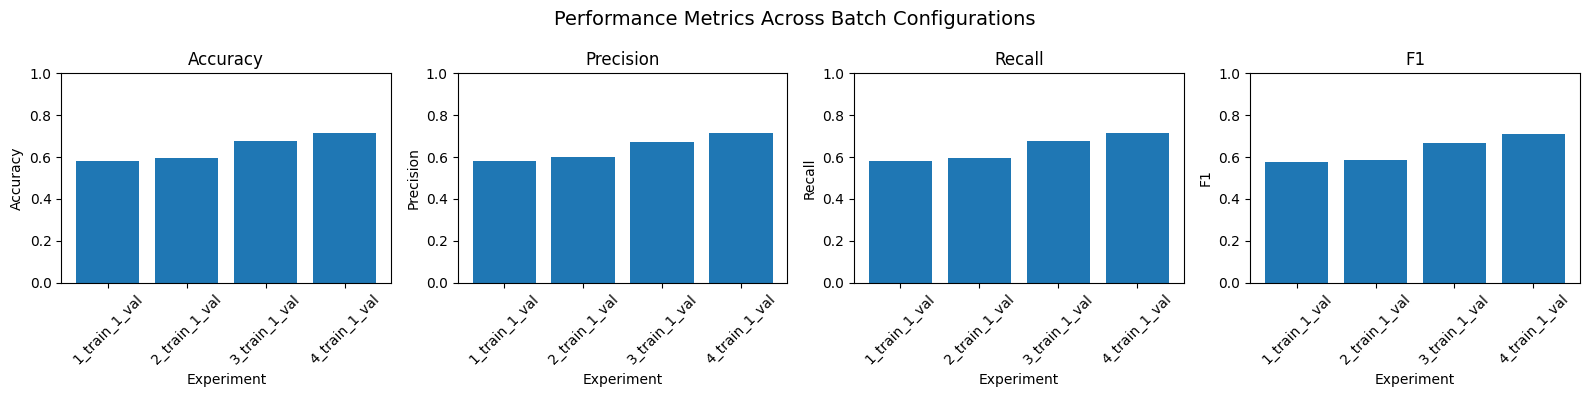


Results summary:
   experiment  train_size  val_size  accuracy  precision  recall       f1
1_train_1_val       10000     10000    0.5816   0.579548  0.5816 0.576670
2_train_1_val       20000     10000    0.5972   0.599978  0.5972 0.584271
3_train_1_val       30000     10000    0.6759   0.671911  0.6759 0.667779
4_train_1_val       40000     10000    0.7158   0.712591  0.7158 0.711027


In [15]:
import matplotlib.pyplot as plt

metric_cols = ["accuracy", "precision", "recall", "f1"]

fig, axes = plt.subplots(1, len(metric_cols), figsize=(16, 4))

for ax, metric in zip(axes, metric_cols):
    ax.bar(results_df["experiment"], results_df[metric])
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Experiment")
    ax.set_ylabel(metric.capitalize())
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, 1)

fig.suptitle("Performance Metrics Across Batch Configurations", fontsize=14)
fig.tight_layout()
plt.show()

print("\nResults summary:")
print(results_df[["experiment", "train_size", "val_size"] + metric_cols].to_string(index=False))

# 2.7 Code quality checks

In [16]:
import re
import subprocess
import tempfile

notebook_path = "labs/lab02/notebooks/ml_engineering_lab_02.ipynb"

# Export notebook to a temporary Python script
with tempfile.NamedTemporaryFile(suffix=".py", prefix="nb_check_", delete=False, mode="w") as tmp:
    tmp_path = tmp.name

# Use nbconvert to export
subprocess.run(
    ["jupyter", "nbconvert", "--to", "script", "--output", tmp_path.replace(".py", ""), notebook_path],
    check=True,
    capture_output=True,
)

# Clean up cell markers and magic commands
with open(tmp_path) as f:
    lines = f.readlines()

cleaned_lines = [
    line for line in lines
    if not re.match(r"^# In\[", line)
    and not re.match(r"^get_ipython\(\)", line)
    and not line.strip().startswith("!")
]

with open(tmp_path, "w") as f:
    f.writelines(cleaned_lines)

# --- Run checks ---
print("$ isort --check --profile black --line-length 100 nb_check.py")
result = subprocess.run(
    ["isort", "--check", "--profile", "black", "--line-length", "100", tmp_path],
    capture_output=True, text=True,
)
if result.returncode == 0:
    print("\u2713 No issues found\n")
else:
    print(result.stdout)
    print(result.stderr, "\n")

print("$ ruff check --ignore E402 nb_check.py")
result = subprocess.run(
    ["ruff", "check", "--ignore", "E402", tmp_path],
    capture_output=True, text=True,
)
if result.returncode == 0:
    print("All checks passed!\n")
else:
    print(result.stdout)
    print(result.stderr, "\n")

print("$ mypy --ignore-missing-imports nb_check.py")
result = subprocess.run(
    ["mypy", "--ignore-missing-imports", tmp_path],
    capture_output=True, text=True,
)
if result.returncode == 0:
    print("Success: no issues found in 1 source file")
else:
    print(result.stdout)
    print(result.stderr)

# Cleanup
Path(tmp_path).unlink(missing_ok=True)

CalledProcessError: Command '['jupyter', 'nbconvert', '--to', 'script', '--output', '/tmp/nb_check_wgd8n7nt', 'labs/lab02/notebooks/ml_engineering_lab_02.ipynb']' returned non-zero exit status 1.